In [7]:
import tensorflow as tf 
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.applications import EfficientNetB0 
from tensorflow.keras import layers, models 
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint 
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
train_dir = "../smartvision_dataset/classification/train"
val_dir = "../smartvision_dataset/classification/val"
test_dir = "../smartvision_dataset/classification/test"

In [4]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.7, 1.3],
    width_shift_range=0.2,
    height_shift_range=0.2
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 1749 images belonging to 25 classes.
Found 375 images belonging to 25 classes.
Found 375 images belonging to 25 classes.


In [ ]:
num_classes = train_data.num_classes

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

In [ ]:
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3),
    ModelCheckpoint("../models/efficientnet_best.h5", save_best_only=True)
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=loss_fn,
    metrics=['accuracy']
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=50,
    callbacks=callbacks
)

- Train accuracy is 86%

In [ ]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

- Test accuracy is 80%

In [ ]:
model = models.load_model("../models/efficientnet_best.h5")
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_data.classes
print(classification_report(y_true, y_pred_classes, target_names=list(test_data.class_indices.keys())))

12/12 ━━━━━━━━━━━━━━━━━━━━ 28s 2s/step
               precision    recall  f1-score   support

     airplane       0.94      1.00      0.97        15
          bed       0.90      0.60      0.72        15
        bench       0.85      0.73      0.79        15
      bicycle       1.00      0.80      0.89        15
         bird       0.87      0.87      0.87        15
       bottle       0.80      0.80      0.80        15
         bowl       0.57      0.53      0.55        15
          bus       0.73      0.73      0.73        15
         cake       0.83      0.67      0.74        15
          car       0.70      0.93      0.80        15
          cat       0.67      0.93      0.78        15
        chair       0.83      1.00      0.91        15
        couch       0.80      0.53      0.64        15
          cow       0.82      0.93      0.88        15
          cup       0.67      0.67      0.67        15
          dog       0.69      0.60      0.64        15
     elephant       0.94 

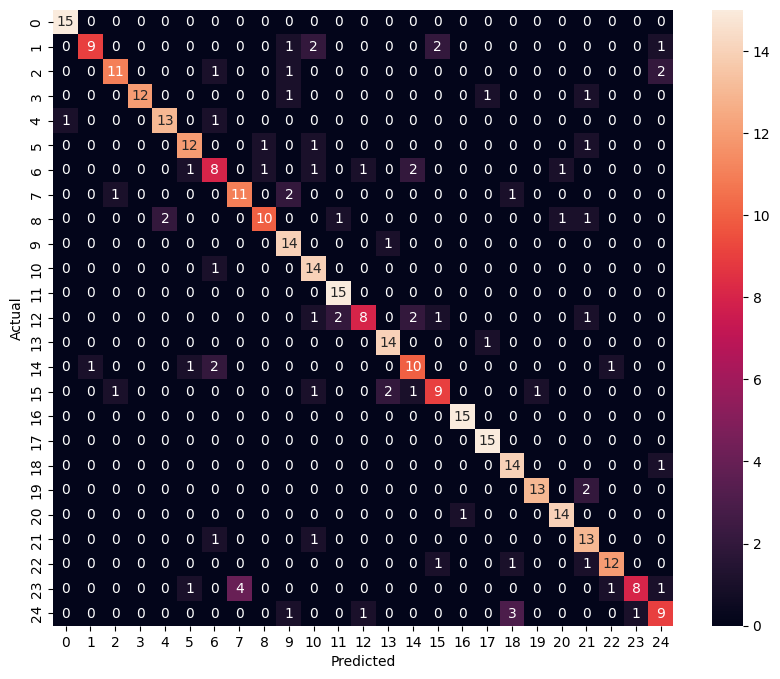

In [11]:
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()